# 202 — GST design tutorial (fst_to_gst)

This short tutorial demonstrates converting a fixed-sample design (FSD) into a group-sequential (GST) design using the `fst_to_gst` helpers and shows a minimal example of creating a `BinomialABTest` ledger-backed test. The notebook is intentionally small and uses low `n_sim` values so it runs quickly in the project's test environment (poetry).

Prerequisites:
- This notebook is intended to run inside the project's Poetry environment (e.g. `poetry run jupyter lab` or `poetry run jupyter nbconvert --execute ...`).
- We use small simulation counts (`n_sim`) so CI and local iterations stay fast.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Imports: keep these minimal so the notebook runs fast
import os
import ibis
import pprint
import matplotlib.pyplot as plt
import logging
import sys
from tqdm.auto import tqdm
from tqdm.contrib.logging import logging_redirect_tqdm

# Configure logging for this demo/notebook; callers control verbosity via logger levels
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
logger = logging.getLogger(__name__)
from earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst import (
    AddInterimToFixedSampleTest,
)
from earlysign.api.ab_tests import BinomialABTest
from earlysign.stats.essentials.methods.group_sequential.spending import (
    get_spending_class,
)
from earlysign.stats.essentials.schemes.two_proportions.design import (
    build_two_proportions_scheme,
)

pp = pprint.PrettyPrinter(indent=2)

Compute a small GST design by converting an FSD to GST timings and then simulating operating characteristics.
The calls below intentionally use small `n_sim` so they run quickly in CI / local iterative runs.

In [3]:
import numpy as np

# Design parameters (small, demo-friendly)
alpha = 0.05
delta = 0.02  # detectable difference (absolute proportion)
power = 0.8
ks = [2, 3]  # number of analyses to try (kept small for demo/CI)
p_control = 0.10
allocation_ratio = 1.0
n_sim = 200  # very small Monte-Carlo count for a quick demo
batch_size = 100
seed = 123
effect_size_candidates = np.arange(0.01, 0.05, 0.002).tolist()

# Log the effect sizes we'll try in the simulations
logger.info("Effect sizes to try: %s", effect_size_candidates)

# Use a classic Pocock spending for the demo (pass string key)
spending = "pocock"
spending_cls = get_spending_class(spending)
spending_obj = spending_cls(alpha=alpha)
scheme = build_two_proportions_scheme(
    p_control=p_control,
    target_effect=delta,
    effect_sizes=effect_size_candidates,
    alpha=alpha,
    power=power,
    allocation_ratio=allocation_ratio,
)

# Build the canonical design interface (wraps AddInterimToFixedSampleTest)
design_interface = BinomialABTest.design_interface(
    alpha=alpha,
    delta=delta,
    power=power,
    p_control=p_control,
    allocation_ratio=allocation_ratio,
    spending=spending,
    effect_sizes=effect_size_candidates,
    n_sim=n_sim,
    batch_size=batch_size,
    seed=seed,
)

inst = design_interface.design

INFO:__main__:Effect sizes to try: [0.01, 0.012, 0.014, 0.016, 0.018000000000000002, 0.02, 0.022, 0.024, 0.026000000000000002, 0.028, 0.03, 0.032, 0.034, 0.036000000000000004, 0.038, 0.04, 0.042, 0.044, 0.046, 0.048]
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Computed FSD metadata: {'n_fsd_per_group': 3839, 'planned_max_n': 7678, 'fsd_total': 7678}


{'n_fsd_per_group': 3839, 'planned_max_n': 7678, 'fsd_total': 7678}

INFO:__main__:Running compare_interim (keep_power=False) with effect_sizes=[0.01, 0.012, 0.014, 0.016, 0.018000000000000002, 0.02, 0.022, 0.024, 0.026000000000000002, 0.028, 0.03, 0.032, 0.034, 0.036000000000000004, 0.038, 0.04, 0.042, 0.044, 0.046, 0.048]


compare_interim k (no power keep):   0%|          | 0/2 [00:00<?, ?design/s]

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Starting compare_interim(k=2, keep_power=False)
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Timing optimisation (k=2) -> info_times=[0.4884203764, 1.0]
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Using planned_max_n=7678 for k=2


Simulating effect sizes (k=2):   0%|          | 0/20 [00:00<?, ?effect/s]

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Starting compare_interim(k=3, keep_power=False)
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Timing optimisation (k=3) -> info_times=[0.3669100238, 0.6149194787, 1.0]
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Using planned_max_n=7678 for k=3


Simulating effect sizes (k=3):   0%|          | 0/20 [00:00<?, ?effect/s]

=== k=2 ===
planned_max_n: 7678
n_per_analysis: 1920
power_at_delta: 0.79
sample_sizes: [3751, 7678]
n_fsd_per_group (if present): 3839
fsd_total (if present): 7678
=== k=3 ===
planned_max_n: 7678
n_per_analysis: 1280
power_at_delta: 0.795
sample_sizes: [2818, 4722, 7678]
n_fsd_per_group (if present): 3839
fsd_total (if present): 7678


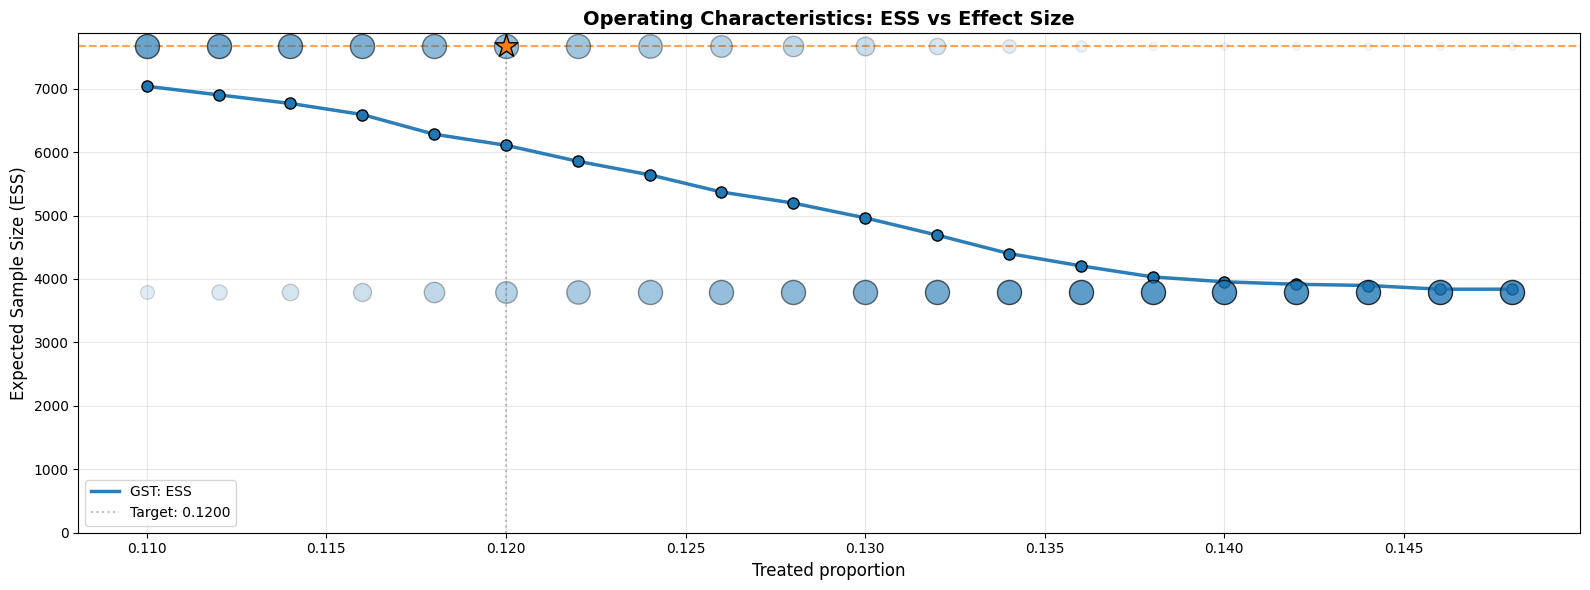

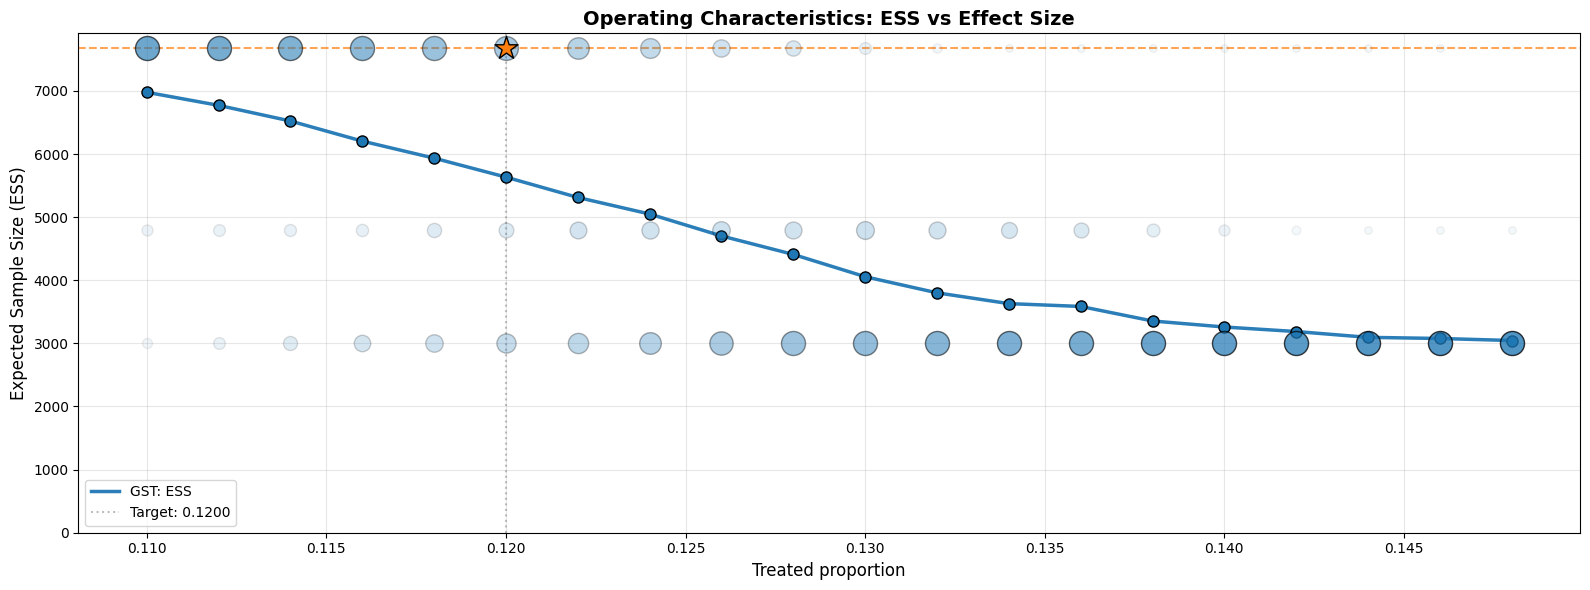

In [4]:
results = {}
logger.info(
    "Running compare_interim (keep_power=False) with effect_sizes=%s",
    effect_size_candidates,
)
with logging_redirect_tqdm(loggers=[logger]):
    for k in tqdm(ks, desc="compare_interim k (no power keep)", unit="design"):
        logger.debug(
            "Evaluating compare_interim with k=%s keep_power=False",
            k,
        )
        results[k] = inst.compare_interim(k=k, plot_options={"y_bottom": 0})

# # Summarize results
# for k, meta in results.items():
#     print(f"=== k={k} analyses ===")
#     if isinstance(meta, dict):
#         print("Keys available:", sorted(list(meta.keys())))
#         print("power_at_delta:", meta.get("power_at_delta"))
#     else:
#         print("Result for k=", k, " ->", repr(meta))

# Per-k metadata inspection for interactive debugging
for k, meta in results.items():
    print(f"=== k={k} ===")
    if isinstance(meta, dict):
        print("planned_max_n:", meta.get("planned_max_n"))
        print("n_per_analysis:", meta.get("n_per_analysis"))
        print("power_at_delta:", meta.get("power_at_delta"))
        # Inspect oc_results metadata nearest to the target effect size (delta)
        oc = meta.get("oc_results", [])
        if oc:
            # oc is expected to be a list of OCPointResult objects; metadata contains sample sizes
            closest = min(oc, key=lambda r: abs(r.effect_size - float(delta)))
            md = getattr(closest, "metadata", {}) or {}
            print("sample_sizes:", md.get("sample_sizes"))
            print("n_fsd_per_group (if present):", md.get("n_fsd_per_group"))
            print("sample_size (if present):", md.get("sample_size"))
    else:
        print("Result is not a dict:", repr(meta))

INFO:__main__:Running compare_interim (keep_power=True) with effect_sizes=[0.01, 0.012, 0.014, 0.016, 0.018000000000000002, 0.02, 0.022, 0.024, 0.026000000000000002, 0.028, 0.03, 0.032, 0.034, 0.036000000000000004, 0.038, 0.04, 0.042, 0.044, 0.046, 0.048]


compare_interim k (keep power):   0%|          | 0/2 [00:00<?, ?design/s]

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Starting compare_interim(k=2, keep_power=True)
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Target power=0.8, tolerance=0.01 (accept range: [target, target+tol])
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Timing optimisation (k=2) -> info_times=[0.4884203764, 1.0]


Power search (k=2): 0candidate [00:00, ?candidate/s]

Estimating power (planned_max_n=15358, info_times=[0.4884203764, 1.0], sampling_meta={'batch_size': 100, 'allocation_ratio': 1.0, 'cumulative_sizes': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000, 5200, 5400, 5600, 5800, 6000, 6200, 6400, 6600, 6800, 7000, 7200, 7400, 7600, 7800, 8000, 8200, 8400, 8600, 8800, 9000, 9200, 9400, 9600, 9800, 10000, 10200, 10400, 10600, 10800, 11000, 11200, 11400, 11600, 11800, 12000, 12200, 12400, 12600, 12800, 13000, 13200, 13400, 13600, 13800, 14000, 14200, 14400, 14600, 14800, 15000, 15200, 15358], 'max_total': 15358})


...

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Estimated power (planned_max_n=7682) -> 0.805


Accepting planned_max_n=7682 with achieved power=0.805 within [0.8, 0.81] (early-stop)


INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Accepting planned_max_n=7682 with achieved power=0.805 within [0.8, 0.81] (early-stop)
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Using planned_max_n=7682 for k=3


Simulating effect sizes (k=3):   0%|          | 0/20 [00:00<?, ?effect/s]

=== k=2 analyses ===
Keys available: ['boundaries', 'design_payload', 'info_times', 'n_per_analysis', 'oc_results', 'planned_max_n', 'plot_axes', 'plot_error', 'power_at_delta', 'procedure_metadata']
power_at_delta: 0.805
=== k=3 analyses ===
Keys available: ['boundaries', 'design_payload', 'info_times', 'n_per_analysis', 'oc_results', 'planned_max_n', 'plot_axes', 'plot_error', 'power_at_delta', 'procedure_metadata']
power_at_delta: 0.805


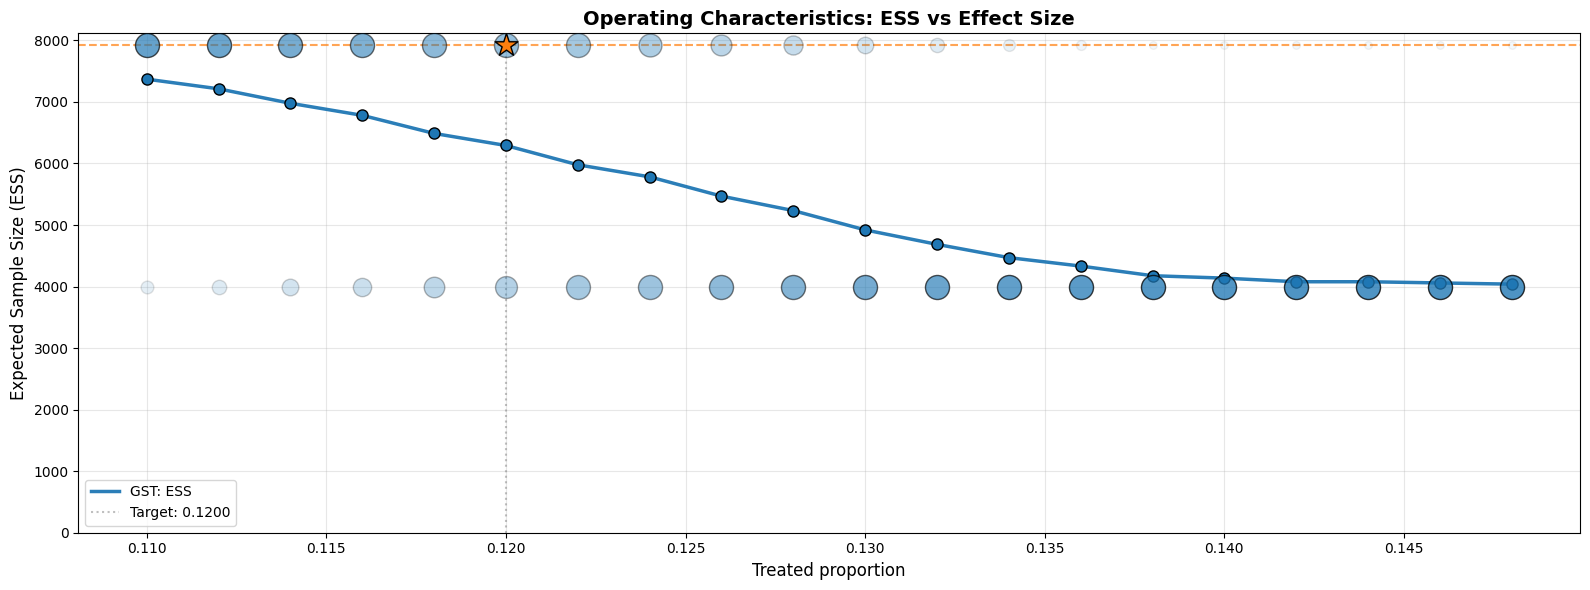

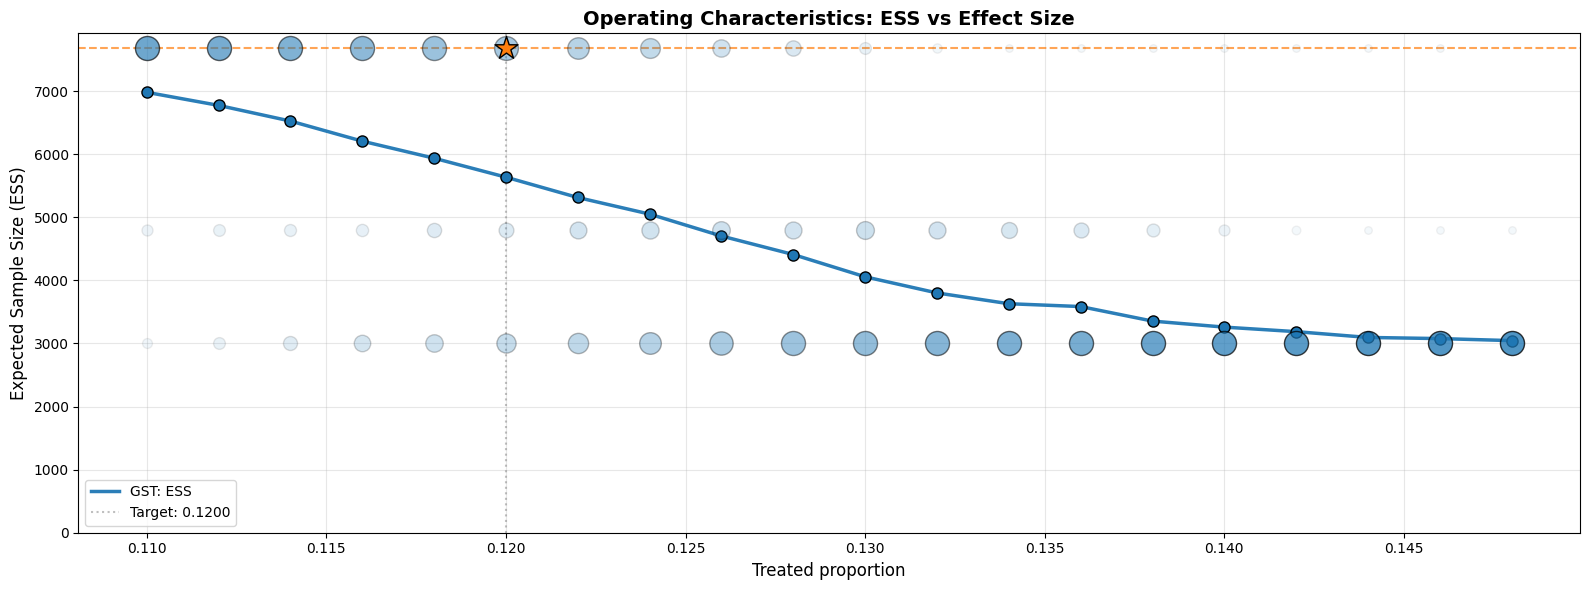

In [5]:
results = {}
logger.info(
    "Running compare_interim (keep_power=True) with effect_sizes=%s",
    effect_size_candidates,
)
scheme_for_keep = scheme.with_effect_sizes(effect_size_candidates)
procedure_factory_keep = scheme_for_keep.procedure_factory_builder(
    spending_obj, allocation_ratio
)
asn_factory_keep = scheme_for_keep.asn_factory_builder(spending_obj)
inst_keep_power = AddInterimToFixedSampleTest(
    alpha=alpha,
    power=power,
    scheme=scheme_for_keep,
    procedure_factory=procedure_factory_keep,
    asn_calculator_factory=asn_factory_keep,
    simulator=scheme_for_keep.simulator_factory(n_sim, allocation_ratio),
    keep_power=True,
    batch_size=batch_size,
    seed=seed,
)
with logging_redirect_tqdm(loggers=[logger]):
    for k in tqdm(ks, desc="compare_interim k (keep power)", unit="design"):
        logger.debug(
            "Evaluating compare_interim with k=%s keep_power=True",
            k,
        )
        results[k] = inst_keep_power.compare_interim(
            k=k,
            plot_options={"y_bottom": 0},
        )

# Summarize results
for k, meta in results.items():
    print(f"=== k={k} analyses ===")
    if isinstance(meta, dict):
        print("Keys available:", sorted(list(meta.keys())))
        print("power_at_delta:", meta.get("power_at_delta"))
    else:
        print("Result for k=", k, " ->", repr(meta))

In [ ]:
# Diagnostic cell: increase n_sim and compare FSD-fixed vs keep_power
# Compare AddInterimToFixedSampleTest with keep_power disabled vs enabled using more simulations.

n_sim_large = 100
print(f"Running comparisons with n_sim = {n_sim_large}")

logger.info(
    "Calling AddInterimToFixedSampleTest (keep_power=False/True) with effect_sizes=%s (n_sim=%d)",
    effect_size_candidates,
    n_sim_large,
)

print("FSD planned_max_n (inst.planned_max_n):", inst.fsd_design.get("sample_size"))

scheme_for_diag = scheme.with_effect_sizes(effect_size_candidates)
procedure_factory_diag = scheme_for_diag.procedure_factory_builder(
    spending_obj, allocation_ratio
)
asn_factory_diag = scheme_for_diag.asn_factory_builder(spending_obj)


def build_helper(keep_power: bool):
    helper = AddInterimToFixedSampleTest(
        alpha=alpha,
        power=power,
        scheme=scheme_for_diag,
        procedure_factory=procedure_factory_diag,
        asn_calculator_factory=asn_factory_diag,
        simulator=scheme_for_diag.simulator_factory(n_sim_large, allocation_ratio),
        keep_power=keep_power,
        batch_size=batch_size,
        seed=seed,
    )
    return helper


def run_compare(helper):
    collected = {}
    with logging_redirect_tqdm(loggers=[logger]):
        for k in tqdm(ks, desc="compare_interim diagnostics", unit="design"):
            logger.debug("Aggregating diagnostic comparison for k=%s", k)
            collected[int(k)] = helper.compare_interim(
                k=int(k),
                plot_options={"y_bottom": 0},
            )
    return collected


inst_fixed = build_helper(False)
inst_keep = build_helper(True)
res_fixed = run_compare(inst_fixed)
res_keep = run_compare(inst_keep)

summary_lines = []
for k in ks:
    rf = res_fixed[int(k)]
    rk = res_keep[int(k)]
    summary_lines.append(f"\n--- k={k} ---")
    summary_lines.append(
        "FSD-fixed: planned_max_n="
        + str(rf.get("planned_max_n"))
        + ", power_at_delta="
        + str(rf.get("power_at_delta"))
    )
    summary_lines.append(
        "Keep-power: planned_max_n="
        + str(rk.get("planned_max_n"))
        + ", power_at_delta="
        + str(rk.get("power_at_delta"))
    )

print("\n".join(summary_lines))

In [7]:
# Cell: Estimate FSD power by simulation
from earlysign.stats.essentials.methods.group_sequential import simulation
from earlysign.stats.essentials.schemes.two_proportions.simulator import (
    TwoProportionsSimulator,
)

n_sim_fsd = 200

fsd_total_raw = inst.fsd_design.get("sample_size")
if fsd_total_raw is None:
    raise RuntimeError("inst.fsd_design must contain sample_size metadata")
if fsd_total_raw is None:
    raise RuntimeError("inst.fsd_design must contain sample_size metadata")

fsd_total = int(fsd_total_raw)
info_times = [1.0]
procedure_factory = scheme.procedure_factory_builder(spending_obj, allocation_ratio)
procedure = procedure_factory(info_times, fsd_total, None, seed)
fsd_metadata = procedure.snapshot_metadata()
per_group_total = max(1, fsd_total // 2)

sampling_strategy = simulation.FixedBatchSampling(
    size=int(batch_size),
    allocation_ratio=float(allocation_ratio),
    total=int(fsd_total),
)

sim = TwoProportionsSimulator(
    effect_size=delta,
    n_simulations=int(n_sim_fsd),
    allocation_ratio=float(allocation_ratio),
    strategy=sampling_strategy,
)

point = sim.simulate(
    procedure,
    p_control=float(p_control),
    effect_size=float(delta),
    n_simulations=int(n_sim_fsd),
    rng_seed=seed,
    max_total=fsd_total,
    sampling=sampling_strategy,
)

print("FSD planned_max_n:", fsd_total)
print("per_group_total:", per_group_total)
print(
    f"Estimated FSD power at delta={delta} (n_sim={n_sim_fsd}):",
    float(point.power),
)

md = getattr(point, "metadata", {}) or {}
if not md.get("sample_sizes"):
    md.setdefault("sample_sizes", fsd_metadata.get("sample_sizes"))
print("sample_sizes (from metadata):", md.get("sample_sizes"))

FSD planned_max_n: 7678
per_group_total: 3839
Estimated FSD power at delta=0.02 (n_sim=200): 0.79
sample_sizes (from metadata): [7678]


In [8]:
# Demo: form DesignPayloadModel payload from comparison result and call BinomialABTest.set_design()
# The ledger now normalises payloads, so we only need to build a plain-Python dict.

k_choice = 3
variant = "keep"  # "fixed" or "keep"

if variant == "keep":
    meta = res_keep[int(k_choice)]
else:
    meta = res_fixed[int(k_choice)]

planned_max_n = int(meta.get("planned_max_n"))
info_times = list(map(float, meta.get("info_times", [])))

# Build a minimal DesignPayload compatible dict — keep metadata intentionally small
design_payload = design_interface.build_design_payload(
    info_times,
    planned_max_n,
    metadata={
        "generated_from": "fst_to_gst.compare_interim",
        "k": int(k_choice),
    },
)
design_payload["efficacy"]["family"] = spending_obj.name

print("Design payload (summary):")
print(" planned_max_n:", design_payload["planned_max_n"])
print(" planned_info_times:", design_payload["planned_info_times"])
print(" efficacy.family:", design_payload["efficacy"]["family"])

# Create an in-memory BinomialABTest and set design
conn = ibis.connect("duckdb://:memory:")
test = BinomialABTest(conn, "demo_experiment_design_demo")
print("Calling test.set_design(...) with the assembled payload...")
test.set_design(design_payload)

# Confirm saved payload
from earlysign.integration.execution.methods.group_sequential.records.design import (
    GroupSequentialDesignRecord,
)

design_record = GroupSequentialDesignRecord("design").attach(test.ledger)
df = design_record.latest().select(payload=design_record.t.payload).execute()
if len(df) > 0:
    payload = df.iloc[0]["payload"]
    print("Design saved — keys:", list(payload.keys()))
    print("planned_max_n:", payload.get("planned_max_n"))
    print("planned_info_times:", payload.get("planned_info_times"))
else:
    raise RuntimeError("No design found after set_design(); investigation required")

Design payload (summary):
 planned_max_n: 7921
 planned_info_times: [0.3669100238, 0.6149194787, 1.0]
 efficacy.family: pocock
Calling test.set_design(...) with the assembled payload...
Design saved — keys: ['alpha', 'efficacy', 'futility', 'hypothesis', 'metadata', 'planned_info_times', 'planned_max_n', 'statistic']
planned_max_n: 7921
planned_info_times: [0.3669100238, 0.6149194787, 1.0]


In [9]:
test.ledger.show().iloc[0]["payload"]

{'alpha': 0.05,
 'efficacy': {'alpha_levels': None,
  'family': 'pocock',
  'fixed_thresholds': None,
  'gamma': None,
  'style': 'alpha_spending'},
 'futility': {'beta': None,
  'binding_mode': 'non_binding',
  'family': None,
  'gamma': None,
  'mode': 'none',
  'z': None},
 'hypothesis': {'description': None,
  'structure': 'two_sided_symmetric',
  'tail': None},
 'metadata': {'generated_from': 'fst_to_gst.compare_interim', 'k': 3},
 'planned_info_times': [0.3669100238, 0.6149194787, 1.0],
 'planned_max_n': 7921,
 'statistic': {'kind': 'wald_z', 'metadata': None, 'scale': 'z'}}

Minimal `BinomialABTest` example

Here we create a ledger-backed `BinomialABTest` instance. This demonstrates the ledger wiring; we avoid running a full sequential update in this demo to keep the cell fast and side-effect free.

In [10]:
# Create an in-memory DuckDB-backed BinomialABTest (no operations performed)
conn = ibis.connect("duckdb://:memory:")
test = BinomialABTest(conn, "demo_experiment")
print("Created BinomialABTest with experiment_id =", test.experiment_id)

# You can inspect the ledger or call test.plot_design() after setting a design.
print("Ledger attached (type):", type(test.ledger))

Created BinomialABTest with experiment_id = demo_experiment
Ledger attached (type): <class 'earlysign.core.ledger.Ledger'>


## Example: using AddInterimToFixedSampleTest with BinomialABTest

This short example shows how to (a) create or reuse an `AddInterimToFixedSampleTest` helper, (b) derive a compact GST design for a chosen `k`, and (c) persist a minimal design payload into a `BinomialABTest` ledger using `set_design()`.

The demo keeps the payload minimal (no large previews) and uses small `n_sim` values in the function call so it runs quickly in interactive environments.


Creating AddInterimToFixedSampleTest (n_sim=100)...
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Computed FSD metadata: {'n_fsd_per_group': 3839, 'planned_max_n': 7678, 'fsd_total': 7678}
Running compare_interim(k=3, keep_power=True) on the class instance...
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Starting compare_interim(k=3, keep_power=True)


INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Target power=0.8, tolerance=0.01 (accept range: [target, target+tol])
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Timing optimisation (k=3) -> info_times=[0.3669100238, 0.6149194787, 1.0]


Power search (k=3): 0candidate [00:00, ?candidate/s]

Estimating power (planned_max_n=15359, info_times=[0.3669100238, 0.6149194787, 1.0], sampling_meta={'batch_size': 100, 'allocation_ratio': 1.0, 'cumulative_sizes': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000, 5200, 5400, 5600, 5800, 6000, 6200, 6400, 6600, 6800, 7000, 7200, 7400, 7600, 7800, 8000, 8200, 8400, 8600, 8800, 9000, 9200, 9400, 9600, 9800, 10000, 10200, 10400, 10600, 10800, 11000, 11200, 11400, 11600, 11800, 12000, 12200, 12400, 12600, 12800, 13000, 13200, 13400, 13600, 13800, 14000, 14200, 14400, 14600, 14800, 15000, 15200, 15359], 'max_total': 15359})


INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Estimating power (planned_max_n=15359, info_times=[0.3669100238, 0.6149194787, 1.0], sampling_meta={'batch_size': 100, 'allocation_ratio': 1.0, 'cumulative_sizes': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200, 3400, 3600, 3800, 4000, 4200, 4400, 4600, 4800, 5000, 5200, 5400, 5600, 5800, 6000, 6200, 6400, 6600, 6800, 7000, 7200, 7400, 7600, 7800, 8000, 8200, 8400, 8600, 8800, 9000, 9200, 9400, 9600, 9800, 10000, 10200, 10400, 10600, 10800, 11000, 11200, 11400, 11600, 11800, 12000, 12200, 12400, 12600, 12800, 13000, 13200, 13400, 13600, 13800, 14000, 14200, 14400, 14600, 14800, 15000, 15200, 15359], 'max_total': 15359})


...

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Estimated power (planned_max_n=7921) -> 0.8


Accepting planned_max_n=7921 with achieved power=0.8 within [0.8, 0.81] (early-stop)


INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Accepting planned_max_n=7921 with achieved power=0.8 within [0.8, 0.81] (early-stop)
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Using planned_max_n=7921 for k=3


Simulating effect sizes (k=3):   0%|          | 0/20 [00:00<?, ?effect/s]

Calling test.set_design(...) with minimal payload from class-based flow...
Design saved — keys: ['alpha', 'efficacy', 'futility', 'hypothesis', 'metadata', 'planned_info_times', 'planned_max_n', 'statistic']
planned_max_n: 7921
planned_info_times: [0.3669100238, 0.6149194787, 1.0]


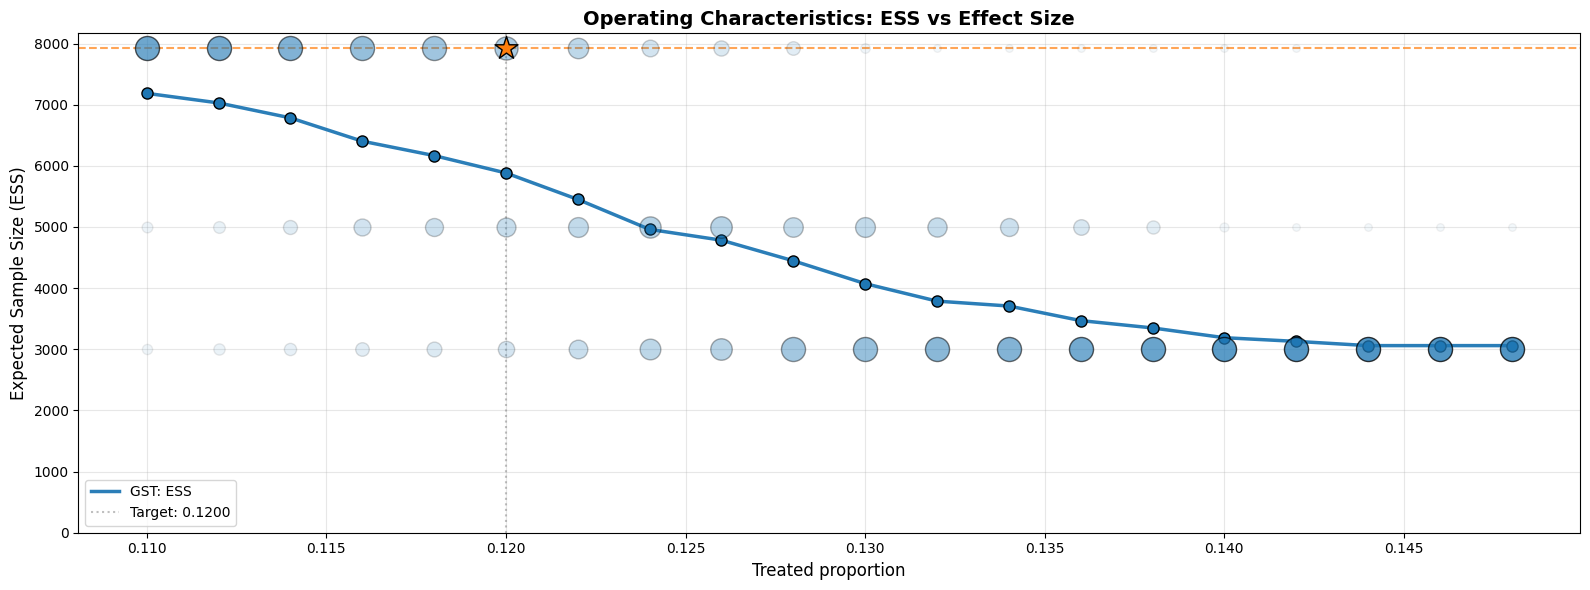

In [11]:
# Demo: derive a minimal GST design using AddInterimToFixedSampleTest (class) and persist via BinomialABTest
# and store the resulting design in an in-memory ledger.

k_choice = 3
n_sim_demo = 100  # small for interactive demo; increase for precision

print()
scheme_for_demo = scheme.with_effect_sizes(effect_size_candidates)
procedure_factory = scheme_for_demo.procedure_factory_builder(
    spending_obj, allocation_ratio
)
asn_factory = scheme_for_demo.asn_factory_builder(spending_obj)
demo_inst = AddInterimToFixedSampleTest(
    alpha=alpha,
    power=power,
    scheme=scheme_for_demo,
    procedure_factory=procedure_factory,
    asn_calculator_factory=asn_factory,
    simulator=scheme_for_demo.simulator_factory(n_sim_demo, allocation_ratio),
    keep_power=True,
    batch_size=batch_size,
    seed=seed,
)


print(
    f"Running compare_interim(k={k_choice}) with keep_power=True on the class instance..."
)
meta = demo_inst.compare_interim(
    k=k_choice,
    plot_options={"y_bottom": 0},
)

if not isinstance(meta, dict):
    raise RuntimeError(
        "compare_interim did not return metadata dict; check earlier steps"
    )

planned_max_n = int(meta.get("planned_max_n"))
planned_info_times = list(map(float, meta.get("info_times", [])))

# Minimal JSON-serializable payload (no heavy previews)
design_payload = design_interface.build_design_payload(
    planned_info_times,
    planned_max_n,
    metadata={
        "generated_from": "AddInterimToFixedSampleTest.compare_interim",
        "k": int(k_choice),
    },
)
design_payload["efficacy"]["family"] = spending_obj.name

# Persist into an in-memory BinomialABTest ledger
conn = ibis.connect("duckdb://:memory:")
test = BinomialABTest(conn, f"demo_class_design_k{k_choice}")
print("Calling test.set_design(...) with minimal payload from class-based flow...")
test.set_design(design_payload)

# Confirm saved payload
from earlysign.integration.execution.methods.group_sequential.records.design import (
    GroupSequentialDesignRecord,
)

design_record = GroupSequentialDesignRecord("design").attach(test.ledger)
df = design_record.latest().select(payload=design_record.t.payload).execute()
if len(df) == 0:
    raise RuntimeError("No design found after set_design(); investigation required")

payload = df.iloc[0]["payload"]
print("Design saved — keys:", list(payload.keys()))
print("planned_max_n:", payload.get("planned_max_n"))
print("planned_info_times:", payload.get("planned_info_times"))

In [ ]:
# Demo: run the design through BinomialABTest via build_template_procedure_factory
# This reuses the template helper to expose BinomialABTest as a ProcedureFactory
# so we can call AddInterimToFixedSampleTest.compare_interim() against the ledger-backed flow.

from earlysign.integration.design.group_sequential.initial_design.helpers.template_helpers import (
    build_template_procedure_factory,
)
from earlysign.stats.essentials.methods.group_sequential import simulation
from earlysign.stats.essentials.schemes.two_proportions.simulator import (
    TwoProportionsSimulator,
)


# Template factory that the helper will call with an ibis backend
def _template_factory(backend, experiment_id, table_name):
    return BinomialABTest(backend, experiment_id)


def _stop_decision_fn(template, look):
    status = template.status()
    if getattr(status, "stop_recommended", False):
        return {"reject": True, "reason": "template_stop"}
    return None


def _template_payload_builder(info_times, planned_max_n):
    return {
        "alpha": float(alpha),
        "hypothesis": {"structure": "two_sided_symmetric"},
        "statistic": {"kind": "wald_z", "scale": "z"},
        "efficacy": {
            "style": "alpha_spending",
            "family": spending_obj.name,
        },
        "futility": {"mode": "none", "binding_mode": "non_binding"},
        "planned_max_n": int(planned_max_n),
        "planned_info_times": list(map(float, info_times)),
        "metadata": {
            "generated_from": "template_compare_interim",
            "experiment_id": "sim_template_exp",
        },
    }


template_proc_factory = build_template_procedure_factory(
    template_factory=_template_factory,
    stop_decision_fn=_stop_decision_fn,
    experiment_id="sim_template_exp",
    table_name=None,
)

# Keep the template evaluation lightweight so the notebook stays quick in CI
_template_n_sim = 20

template_scheme = scheme.with_effect_sizes(effect_size_candidates)


def _build_template_helper(keep_power: bool) -> AddInterimToFixedSampleTest:
    helper = AddInterimToFixedSampleTest(
        alpha=alpha,
        power=power,
        scheme=template_scheme,
        procedure_factory=template_proc_factory,
        asn_calculator_factory=template_scheme.asn_factory_builder(spending_obj),
        simulator=template_scheme.simulator_factory(_template_n_sim, allocation_ratio),
        keep_power=keep_power,
        batch_size=batch_size,
        seed=seed,
        design_payload_builder=_template_payload_builder,
    )
    return helper


template_helpers = {
    False: _build_template_helper(False),
    True: _build_template_helper(True),
}

template_results = {"fixed_budget": {}, "keep_power": {}}
for keep_flag, label in ((False, "fixed_budget"), (True, "keep_power")):
    print(f"=== Template compare_interim() label={label} keep_power={keep_flag} ===")
    logger.info(
        "Template compare_interim label=%s keep_power=%s for ks=%s",
        label,
        keep_flag,
        ks,
    )
    section_lines = []
    helper = template_helpers[keep_flag]
    with logging_redirect_tqdm(loggers=[logger]):
        for k in tqdm(
            ks,
            desc=f"template compare_interim ({label})",
            unit="design",
        ):
            logger.debug(
                "Running template compare_interim label=%s k=%s keep_power=%s",
                label,
                k,
                keep_flag,
            )
            meta = helper.compare_interim(k=k, plot_options={"y_bottom": 0})
            template_results[label][k] = meta
            if isinstance(meta, dict):
                section_lines.append(
                    f" {label} k={k}: planned_max_n={meta.get('planned_max_n')}, power_at_delta={meta.get('power_at_delta')}"
                )
            else:
                section_lines.append(f" {label} k={k}: non-dict result -> {repr(meta)}")
    for line in section_lines:
        print(line)

# Optional: run a single simulation using the adapter procedure to confirm wiring
k_template = ks[-1]
meta_keep = template_results["keep_power"].get(k_template)
if not isinstance(meta_keep, dict):
    raise RuntimeError(
        "compare_interim did not return metadata dict for keep_power flow"
    )

_template_info_times = [float(x) for x in meta_keep.get("info_times", [])]
_template_planned_n = int(meta_keep.get("planned_max_n", 0))

if not _template_info_times or not _template_planned_n:
    raise RuntimeError("compare_interim returned empty info_times or planned_max_n")

_adapter_payload = _template_payload_builder(_template_info_times, _template_planned_n)
_template_procedure = template_proc_factory(
    _template_info_times, _template_planned_n, _adapter_payload, seed
)

_sampling_strategy = simulation.InfoTimeSampling(
    info_times=_template_info_times,
    planned_max_n=int(_template_planned_n),
    allocation_ratio=float(allocation_ratio),
)
_sim = TwoProportionsSimulator(
    effect_size=delta,
    n_simulations=1,
    allocation_ratio=allocation_ratio,
    strategy=_sampling_strategy,
)

_expected_calls = len(_template_info_times)
_metadata = _sampling_strategy.metadata()
_cumulative_sizes = _metadata.get("cumulative_sizes", [])
print(
    "Adapter simulate (info-time sampling): looks=",
    _expected_calls,
    "cumulative_sizes=",
    _cumulative_sizes,
)

print("Running simulator via TemplateProcedureAdapter...")
_template_point = _sim.simulate(
    _template_procedure,
    p_control=float(p_control),
    effect_size=float(delta),
    n_simulations=1,
    rng_seed=seed,
    max_total=_template_planned_n,
    sampling=_sampling_strategy,
)

print("Adapter simulation power:", float(_template_point.power))
print(
    "Adapter metadata sample keys:",
    list((getattr(_template_point, "metadata", {}) or {}).keys()),
)

ledger = getattr(getattr(_template_procedure, "template", None), "ledger", None)
if ledger is not None:
    print()
    print("Adapter template ledger snapshot (head):")
    print(ledger.show().head())
else:
    print("Template procedure did not expose a ledger instance.")

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Computed FSD metadata: {'n_fsd_per_group': 3839, 'planned_max_n': 7678, 'fsd_total': 7678}
=== Template compare_interim() label=fixed_budget keep_power=False ===
INFO:__main__:Template compare_interim label=fixed_budget keep_power=False for ks=[2, 3]


template compare_interim (fixed_budget):   0%|          | 0/2 [00:00<?, ?design/s]

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Starting compare_interim(k=2, keep_power=False)
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Timing optimisation (k=2) -> info_times=[0.4884203764, 1.0]
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Using planned_max_n=7678 for k=2


Simulating effect sizes (k=2):   0%|          | 0/20 [00:00<?, ?effect/s]

Next steps / pointers:
- Use `AddInterimToFixedSampleTest(..., keep_power=True)` to search for a minimal budget that preserves a target power.
- Integrate the returned design payload into `BinomialABTest.set_design(...)` if you want to run ledger-backed simulations and updates.
- For CI and fast experimentation, keep `n_sim` small (e.g. 100-500) and increase for final runs.


### Batched two-proportions procedure

The simulator can drive a batched procedure that evaluates all simulations in one vectorised pass. The example below reuses the existing design helpers but swaps in the new `TwoProportionsBatchedProcedure`.

In [ ]:
from earlysign.stats.essentials.methods.group_sequential import simulation
from earlysign.stats.essentials.methods.group_sequential.spending import OBFSpending
from earlysign.stats.essentials.schemes.two_proportions.procedure import (
    TwoProportionsBatchedProcedure,
)
from earlysign.stats.essentials.schemes.two_proportions.simulator import (
    TwoProportionsSimulator,
    TwoProportionsSimulationRequest,
)

info_times = [0.25, 0.5, 0.75, 1.0]
planned_max_n = 400
spending = OBFSpending(alpha=0.05, sided=2)
procedure_factory = TwoProportionsBatchedProcedure.factory_builder(
    spending_obj=spending,
    alpha=0.05,
    allocation_ratio=1.0,
)
procedure = procedure_factory(
    info_times=info_times,
    planned_max_n=planned_max_n,
    design_payload=None,
    rng_seed=123,
)
strategy = simulation.InfoTimeSampling(
    info_times=info_times,
    planned_max_n=planned_max_n,
    allocation_ratio=1.0,
)
simulator = TwoProportionsSimulator(
    effect_size=0.1,
    n_simulations=30,
    allocation_ratio=1.0,
    strategy=None,
)
request = TwoProportionsSimulationRequest(
    p_control=0.5,
    effect_size=0.1,
    n_simulations=30,
    max_total=planned_max_n,
    sampling=strategy,
)
result = simulator.simulate(procedure, requests=[request], rng_seed=0)
point = result[0]
(
    point.expected_sample_size,
    point.power,
)

### Batched OC curve replication

To mirror the earlier OC-curve exploration we reuse the batched procedure and simulator, assemble a set of batched simulation requests, and plot the resulting expected-sample-size curve.

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Starting compare_interim(k=2, keep_power=False)
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Timing optimisation (k=2) -> info_times=[0.4884203764, 1.0]
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Using planned_max_n=7678 for k=2


Simulating effect sizes (k=2):   0%|          | 0/20 [00:00<?, ?effect/s]

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Starting compare_interim(k=2, keep_power=False)
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Timing optimisation (k=2) -> info_times=[0.4884203764, 1.0]
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Using planned_max_n=7678 for k=2


Simulating effect sizes (k=2):   0%|          | 0/20 [00:00<?, ?effect/s]

INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Starting compare_interim(k=3, keep_power=False)
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Timing optimisation (k=3) -> info_times=[0.3669100238, 0.6149194787, 1.0]
INFO:earlysign.integration.design.group_sequential.initial_design.scenarios.fst_to_gst:Using planned_max_n=7678 for k=3


Simulating effect sizes (k=3):   0%|          | 0/20 [00:00<?, ?effect/s]

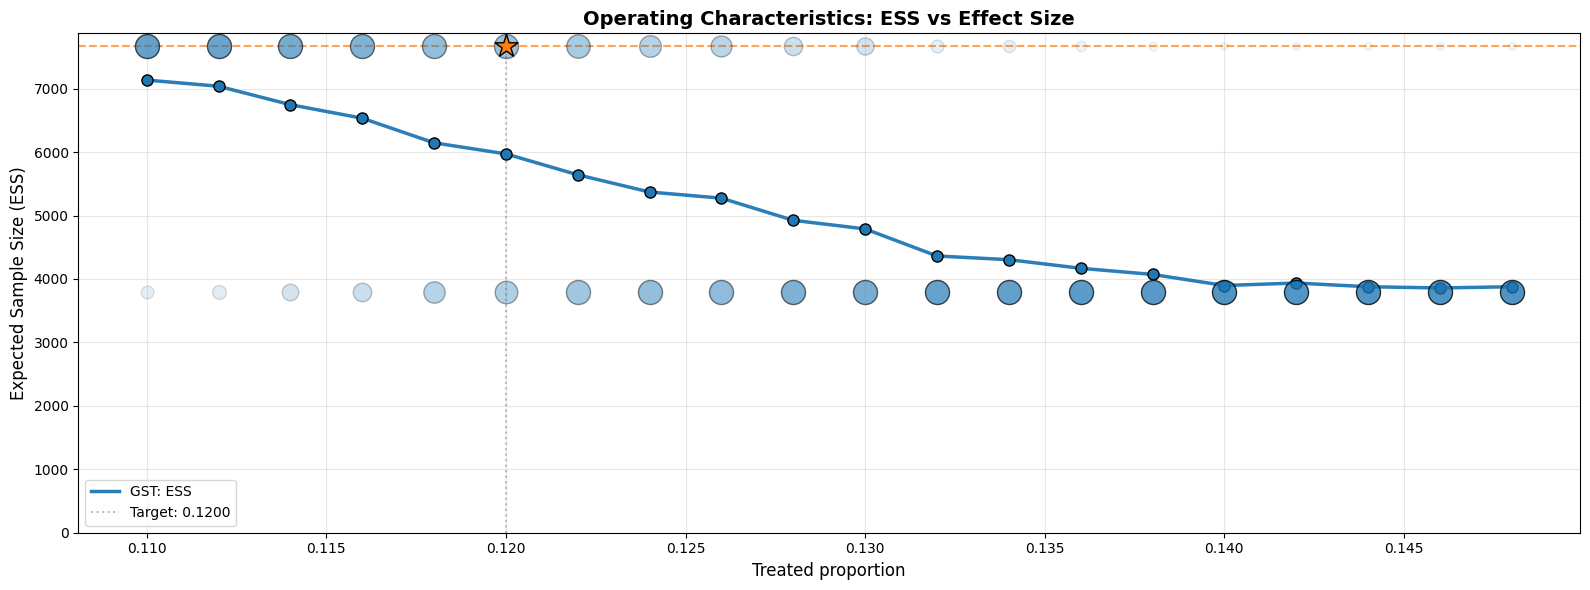

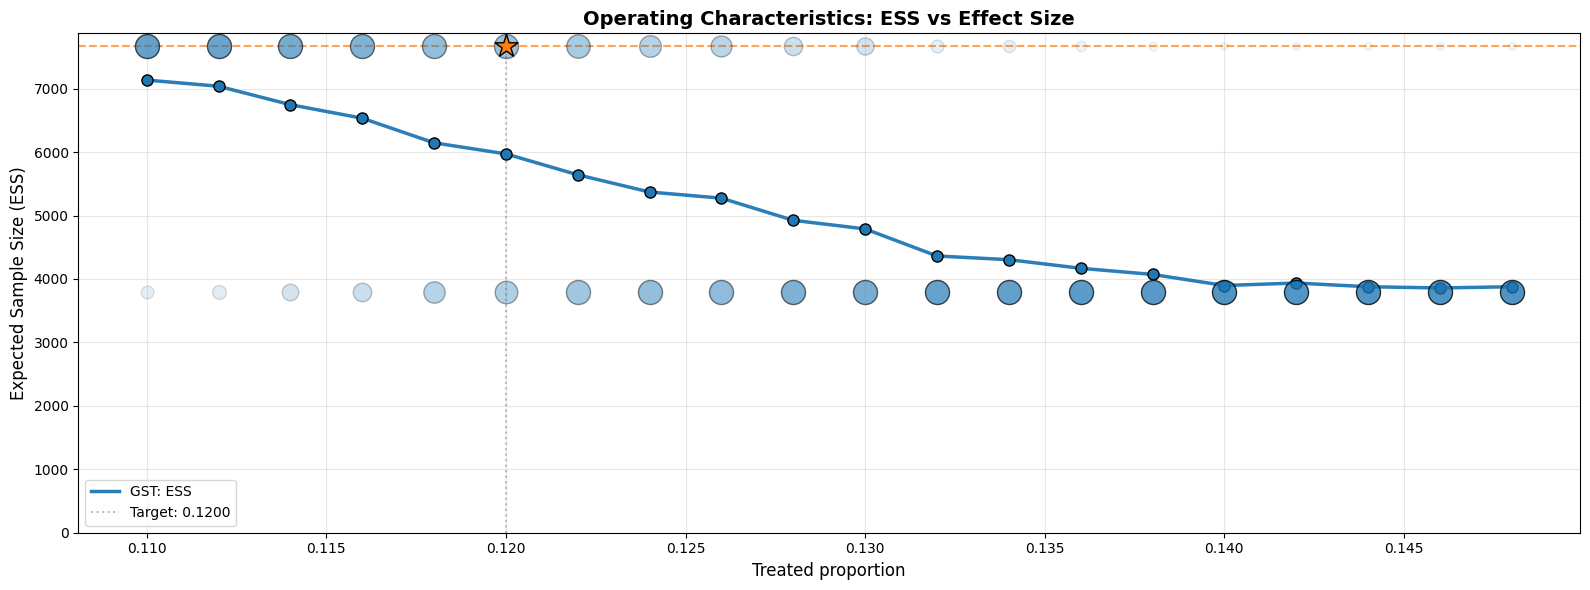

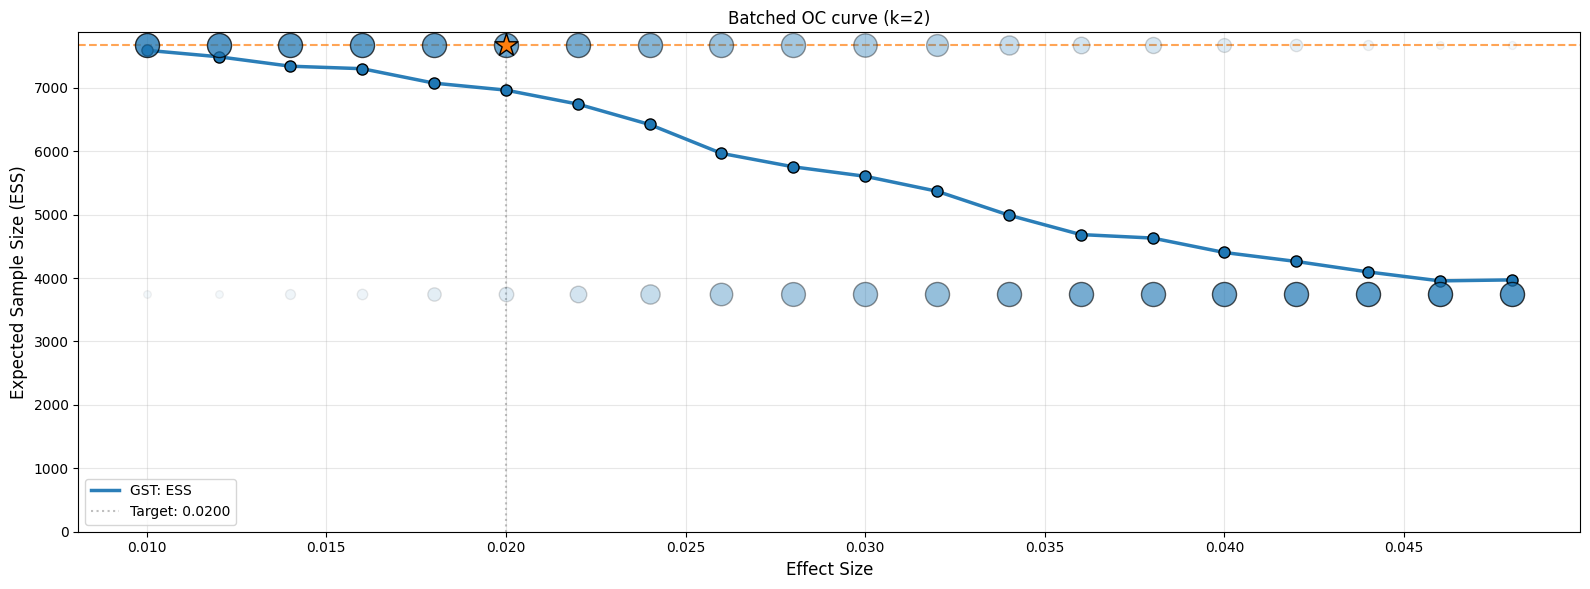

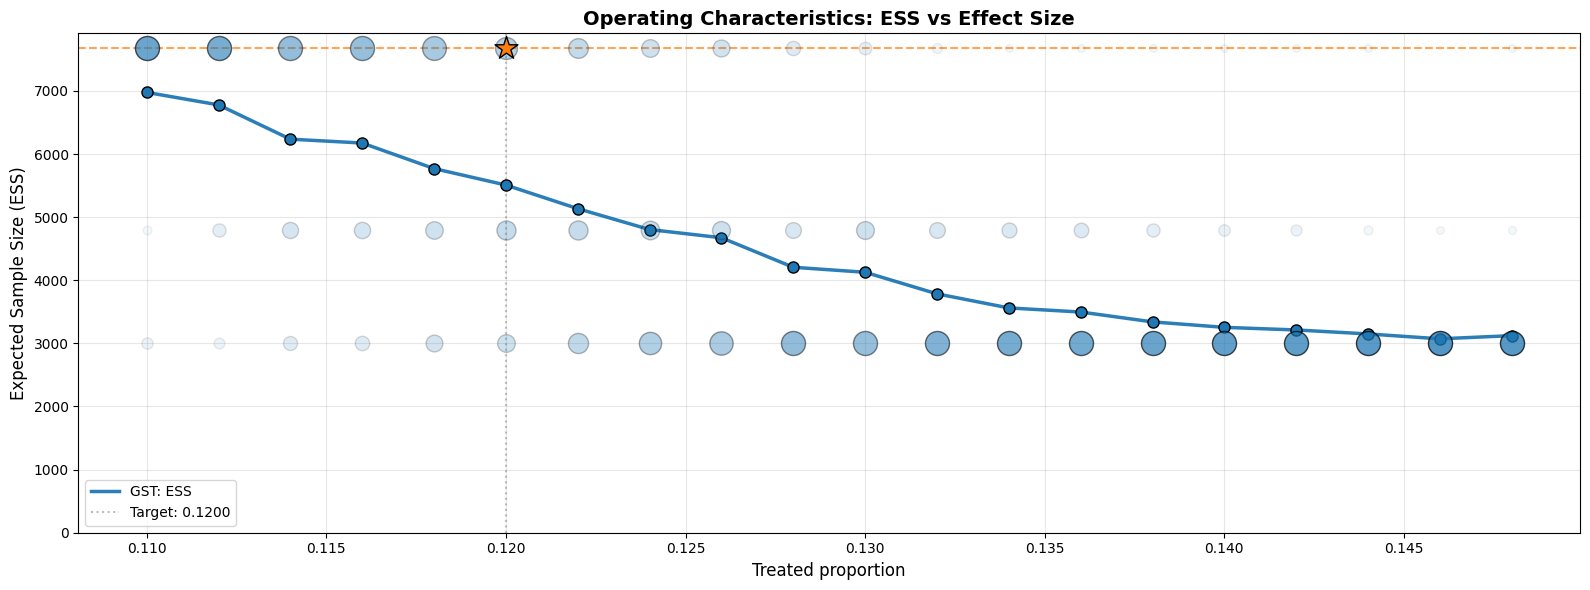

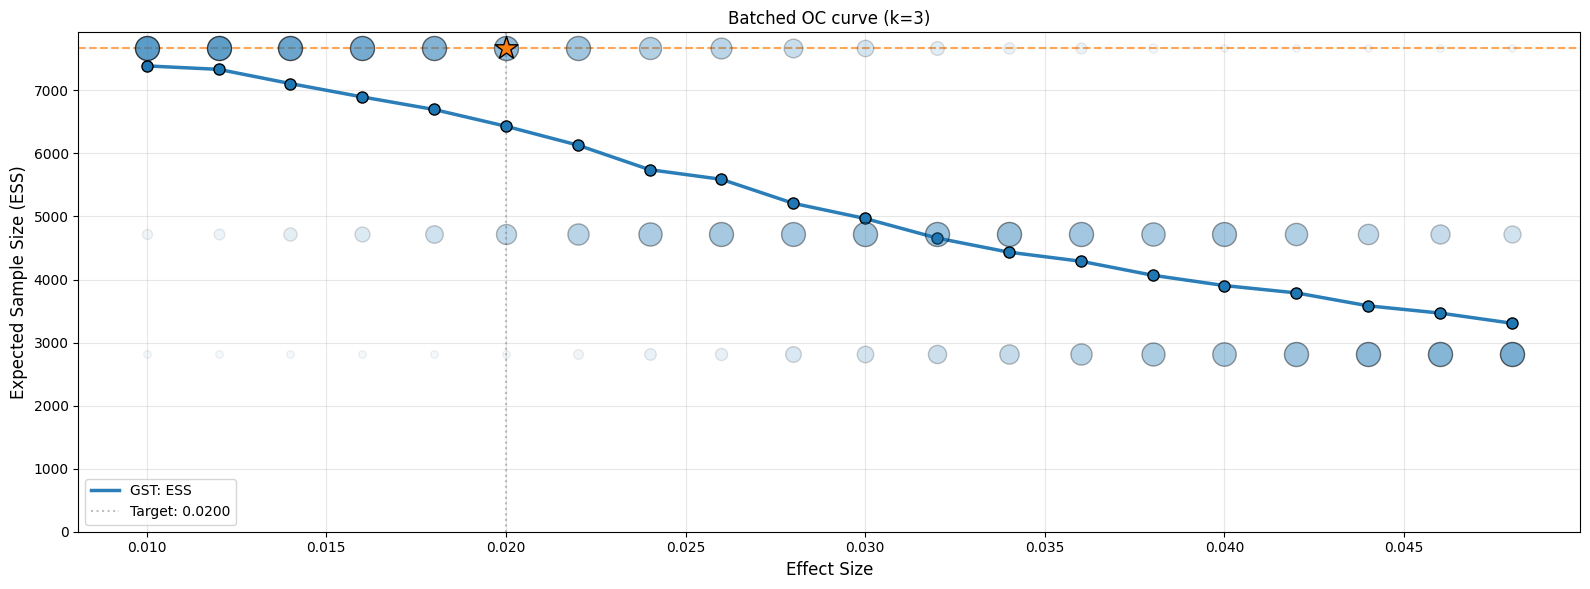

In [24]:
from earlysign.integration.report.group_sequential.plot_oc_curve import (
    OCCurvePlotter,
)

k_ref = int(ks[0])
batched_meta = inst.compare_interim(
    k=k_ref,
    plot_options={"y_bottom": 0},
)
info_times = batched_meta["info_times"]
planned_max_n = int(batched_meta["planned_max_n"])
procedure = procedure_factory(
    info_times=info_times,
    planned_max_n=planned_max_n,
    design_payload=batched_meta.get("design_payload"),
    rng_seed=456,
)
strategy = simulation.InfoTimeSampling(
    info_times=info_times,
    planned_max_n=planned_max_n,
    allocation_ratio=float(allocation_ratio),
)
requests = [
    TwoProportionsSimulationRequest(
        p_control=float(p_control),
        effect_size=float(effect),
        n_simulations=200,
        max_total=planned_max_n,
        sampling=strategy,
    )
    for effect in effect_size_candidates
]
batched_points = simulator.simulate(
    procedure,
    requests=requests,
    rng_seed=1,
)
# plotter = OCCurvePlotter()
# plotter.plot_oc_curve(
#     batched_points,
#     target_effect=float(delta),
#     plot_options={"y_bottom": 0},
# )
plotter = OCCurvePlotter()
batched_results = {}

for k_ref in ks:
    batched_meta = inst.compare_interim(
        k=int(k_ref),
        plot_options={"y_bottom": 0},
    )
    info_times = batched_meta["info_times"]
    planned_max_n = int(batched_meta["planned_max_n"])
    procedure = procedure_factory(
        info_times=info_times,
        planned_max_n=planned_max_n,
        design_payload=batched_meta.get("design_payload"),
        rng_seed=456,
    )
    strategy = simulation.InfoTimeSampling(
        info_times=info_times,
        planned_max_n=planned_max_n,
        allocation_ratio=float(allocation_ratio),
    )
    requests = [
        TwoProportionsSimulationRequest(
            p_control=float(p_control),
            effect_size=float(effect),
            n_simulations=500,
            max_total=planned_max_n,
            sampling=strategy,
        )
        for effect in effect_size_candidates
    ]
    batched_points = simulator.simulate(procedure, requests=requests, rng_seed=1)
    ax = plotter.plot_oc_curve(
        batched_points,
        target_effect=float(delta),
        plot_options={"y_bottom": 0},
    )
    ax.set_title(f"Batched OC curve (k={k_ref})")
    batched_results[k_ref] = (batched_points, ax)